In [109]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

In [110]:
df = pd.read_csv("shop_smart_ecommerce.csv")

In [111]:
df.info()
df.isnull().sum()
df.select_dtypes(include="object").nunique()
df["VisitorType"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

array(['Returning_Visitor', 'New_Visitor', 'Other'], dtype=object)

# EDA (Exploratory Data Analysis)

In [112]:
pd.crosstab(
    df["VisitorType"],
    df["Revenue"],
    normalize="index"
)

Revenue,False,True
VisitorType,,
New_Visitor,0.750885,0.249115
Other,0.811765,0.188235
Returning_Visitor,0.860677,0.139323


In [113]:
pd.crosstab(
    df["Weekend"],
    df["Revenue"],
    normalize="index"
)

Revenue,False,True
Weekend,,
False,0.851089,0.148911
True,0.826011,0.173989


In [114]:
pd.crosstab(
    df["Month"],
    df["Revenue"],
    normalize="index"
)

Revenue,False,True
Month,,
Aug,0.824480,0.175520
Dec,0.874928,0.125072
Feb,0.983696,0.016304
Jul,0.847222,0.152778
June,0.899306,0.100694
Mar,0.899318,0.100682
May,0.891498,0.108502
Nov,0.746498,0.253502
Oct,0.790528,0.209472


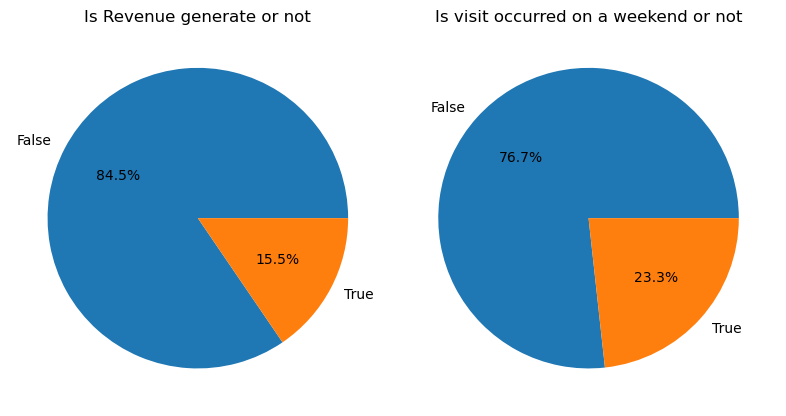

In [115]:
fig, ax = plt.subplots(1, 2, figsize=(8, 8))

classes_count = df["Revenue"].value_counts().reindex([False, True])
ax[0].pie(classes_count, labels=["False", "True"], autopct = "%1.1f%%")
ax[0].set_title("Is Revenue generate or not")

weekend_count = df["Weekend"].value_counts().reindex([False, True])
ax[1].pie(weekend_count, labels=["False", "True"], autopct = "%1.1f%%")
ax[1].set_title("Is visit occurred on a weekend or not")

plt.tight_layout()
plt.show()

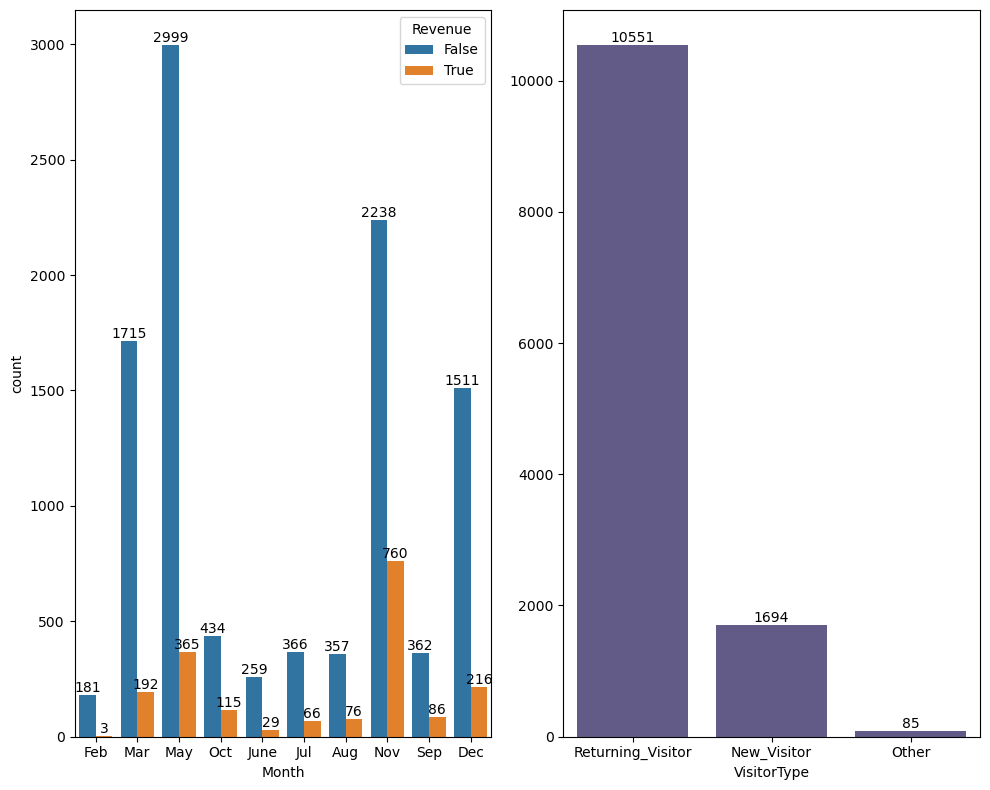

In [116]:
# explore month and VisitorType features

fig , ax = plt.subplots(1, 2, figsize = (10,8))

month_cnt = df["Month"].value_counts()
sns.countplot(
    data=df,
    x="Month",
    hue="Revenue",
    ax=ax[0]
)

ax[0].bar_label(ax[0].containers[0])
ax[0].bar_label(ax[0].containers[1])

visitor_cnt = df["VisitorType"].value_counts()
sns.barplot(x=visitor_cnt.index, y=visitor_cnt.values, ax=ax[1], color = "#5E548E")
ax[1].bar_label(ax[1].containers[0])

plt.tight_layout()
plt.show()

# Encode the target (Revenue)

In [117]:
df["Revenue"] = df["Revenue"].map({False: 0, True: 1}).astype(int)
df["Weekend"] = df["Weekend"].map({False: 0, True: 1}).astype(int)

# Train Test Split

In [118]:
X = df.drop(columns = "Revenue")
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# Feature Encoding

In [119]:
# one-hot Encoding

cols = ["VisitorType", "Month"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore", dtype=int)
ohe.fit(X_train[cols])

encoded_cols = ohe.get_feature_names_out(cols)

X_train[encoded_cols] = ohe.transform(X_train[cols])
X_test[encoded_cols] = ohe.transform(X_test[cols])

X_train.drop(columns=cols, inplace=True)
X_test.drop(columns=cols, inplace=True)

In [120]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9864 entries, 4263 to 11430
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 9864 non-null   int64  
 1   Administrative_Duration        9864 non-null   float64
 2   Informational                  9864 non-null   int64  
 3   Informational_Duration         9864 non-null   float64
 4   ProductRelated                 9864 non-null   int64  
 5   ProductRelated_Duration        9864 non-null   float64
 6   BounceRates                    9864 non-null   float64
 7   ExitRates                      9864 non-null   float64
 8   PageValues                     9864 non-null   float64
 9   SpecialDay                     9864 non-null   float64
 10  OperatingSystems               9864 non-null   int64  
 11  Browser                        9864 non-null   int64  
 12  Region                         9864 non-null   in

# Correlation Heatmap

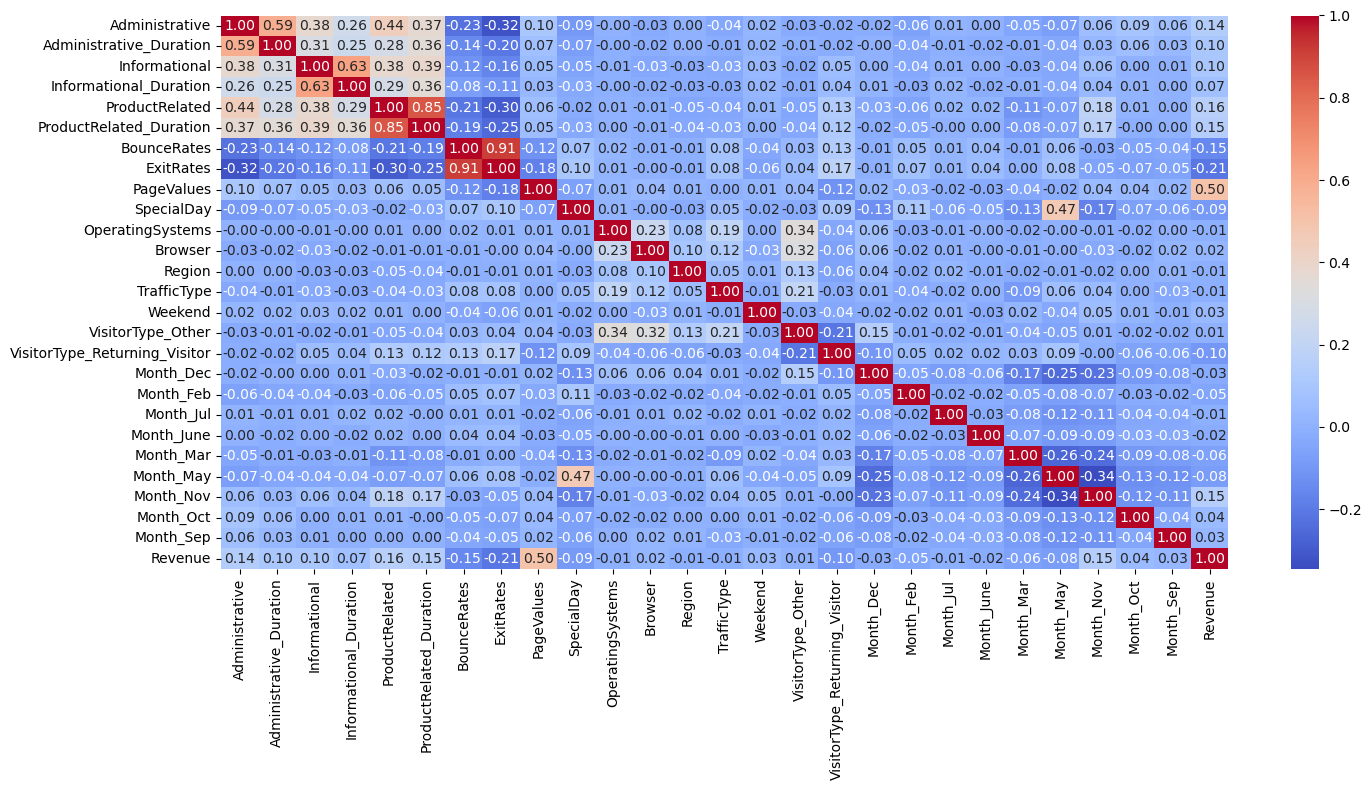

In [121]:
train_with_target = X_train.copy()
train_with_target["Revenue"] = y_train

corr_matrix = train_with_target.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm", 
    annot=True, 
    fmt=".2f"
)
plt.tight_layout()
plt.show()

In [122]:
corr_matrix["Revenue"].sort_values(ascending=False)

Revenue                          1.000000
PageValues                       0.503271
ProductRelated                   0.155596
ProductRelated_Duration          0.145974
Month_Nov                        0.145156
Administrative                   0.142691
Administrative_Duration          0.099236
Informational                    0.097372
Informational_Duration           0.068662
Month_Oct                        0.039634
Weekend                          0.034779
Month_Sep                        0.026729
Browser                          0.022049
VisitorType_Other                0.005042
TrafficType                     -0.007164
Region                          -0.008324
Month_Jul                       -0.011030
OperatingSystems                -0.011793
Month_June                      -0.022896
Month_Dec                       -0.025126
Month_Feb                       -0.047793
Month_Mar                       -0.060998
Month_May                       -0.079300
SpecialDay                      -0

# Fitting model and Evaluate

In [123]:

# Step 1: Pre-pruning
param_grid = {
    "max_depth": [3, 4, 6, 8, None],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [1, 2, 5,]
}

grid = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10}
0.6263777652882035


In [124]:
# Step 2: Best pre-pruned model
best_model = grid.best_estimator_

# Step 3: Obtain pruning path
path = best_model.cost_complexity_pruning_path(X_train, y_train)

alphas = path.ccp_alphas

In [125]:
# Step 4: Find best alpha using CV
alpha_scores = []

for alpha in alphas[:-1]:

    model = DecisionTreeClassifier(
        max_depth=grid.best_params_["max_depth"],
        min_samples_split=grid.best_params_["min_samples_split"],
        min_samples_leaf=grid.best_params_["min_samples_leaf"],
        ccp_alpha=alpha,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    alpha_scores.append(scores.mean())

best_alpha = alphas[np.argmax(alpha_scores)]

print("Best alpha:", best_alpha)

Best alpha: 0.0016835550675892257


In [131]:
# Step 5: Final model
final_model = DecisionTreeClassifier(
    **grid.best_params_,
    ccp_alpha=best_alpha,
    random_state=42
)

final_model.fit(X_train, y_train)

y_prob = final_model.predict_proba(X_test)[:, 1]

best_threshold = 0.35

y_pred = (y_prob >= best_threshold).astype(int)

# y_pred = final_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Test F1: 0.6759142496847415
Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94      2084
           1       0.65      0.70      0.68       382

    accuracy                           0.90      2466
   macro avg       0.80      0.82      0.81      2466
weighted avg       0.90      0.90      0.90      2466

Confusion Matrix:
 [[1941  143]
 [ 114  268]]


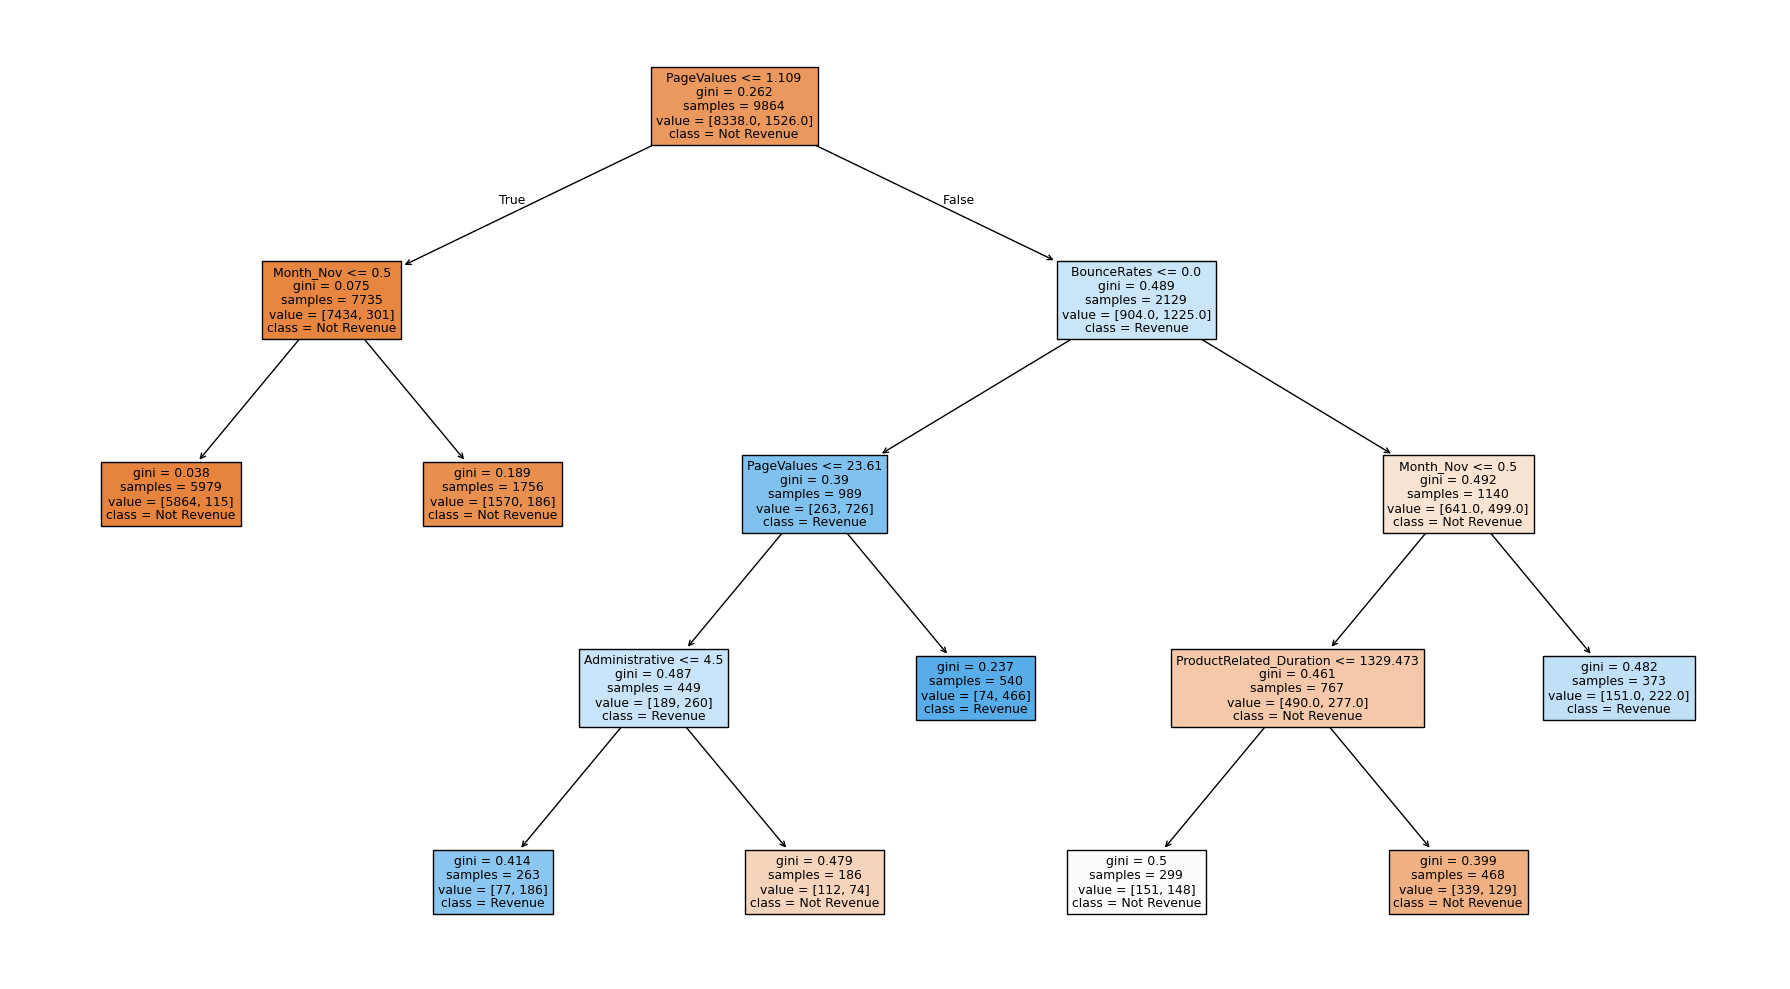

In [132]:
# Plot tree

plt.figure(figsize = (18, 10))
plot_tree(
    final_model,
    feature_names = X_train.columns,
    class_names = ["Not Revenue", "Revenue"],
    filled = True,
   )

plt.tight_layout()
plt.show()

In [133]:
print(final_model.classes_)

[0 1]


# Display Confusion Matrix

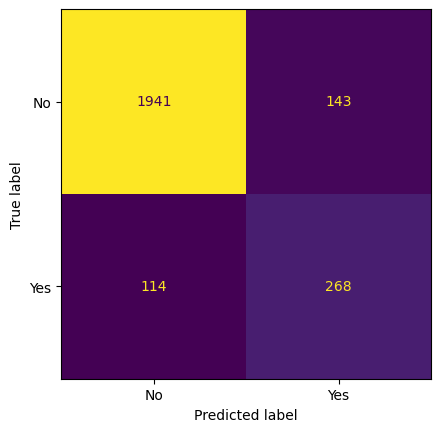

In [134]:
ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(colorbar=False)

In [135]:
feature_importance = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

PageValues                       0.848008
BounceRates                      0.078844
Month_Nov                        0.040591
Administrative                   0.017677
ProductRelated_Duration          0.014879
VisitorType_Other                0.000000
Month_Oct                        0.000000
Month_May                        0.000000
Month_Mar                        0.000000
Month_June                       0.000000
Month_Jul                        0.000000
Month_Feb                        0.000000
Month_Dec                        0.000000
VisitorType_Returning_Visitor    0.000000
TrafficType                      0.000000
Weekend                          0.000000
Administrative_Duration          0.000000
Region                           0.000000
Browser                          0.000000
OperatingSystems                 0.000000
SpecialDay                       0.000000
ExitRates                        0.000000
ProductRelated                   0.000000
Informational_Duration           0

# Save model in the pkl file

In [137]:
import joblib

joblib.dump(final_model, "model.pkl")
joblib.dump(ohe, "encoder.pkl")

print("Model and encoder saved successfully!")

Model and encoder saved successfully!
